# BMI Hand Controller
Ground-up rebuild. Each cell has one job. No silent re-definitions.

**Pipeline stages:**
1. Decode weights → verify power frequency
2. Open-loop validation — confirm muscle head works before any control
3. System identification on the latent wrapper
4. Closed-loop MPC tracking
5. Diagnostics

---
## Stage 0 — Imports and config
All tunable constants live here. Nothing is redefined later.

In [104]:
import numpy as np
import matplotlib.pyplot as plt
import torch
%matplotlib inline

from BMI_and_Hand import BMI_and_Hand
from GG4 import Brain
from Controllers import AugmentedKalmanFilter, ConstrainedMPC
from system_id import extract_full_orthogonal_model

# ── Reproducibility ───────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Trajectory config ─────────────────────────────────────────────────
SHAPE        = "circle"
SIZE         = 60.0          # radius in arm-space units
SPEED        = 0.2        # angular speed in rad/step  (omega = SPEED / SIZE)
SIM_STEPS    = 600           # steps of actual drawing (not including warmup)
WARMUP_STEPS = 75           # steps at zero velocity before drawing starts
                             # must be >= kernel_size of muscle head to fill the conv cache
X2_AMPLITUDE = 8.0   # scale x2 until power gate reaches > 0.9
FEEDFORWARD_GAIN = 1.7# reduce from 5.0 to allow simultaneous multi-channel activation
MAX_AMP          = 5.0 

# ── System ID config ──────────────────────────────────────────────────
N_DOMINANT          = 2      # 2 physical DOFs (X and Y)
N_HIDDEN            = 1      # one hidden state
N_SAMPLES_PER_TRIAL = 400
NUM_TRIALS          = 5
VAF_THRESHOLD       = 0.70   # minimum acceptable VAF — pipeline stops if below this

# ── MPC config ────────────────────────────────────────────────────────
MPC_HORIZON  = 20
MPC_Q        = 1000.0        # state tracking weight
MPC_R        = 10.0          # input effort weight
KF_Q_DIST   = 0.05           # disturbance process noise

print("Config loaded.")
print(f"  Trajectory : {SHAPE}, radius={SIZE}, speed={SPEED} rad/step")
print(f"  Sim steps  : {WARMUP_STEPS} warmup + {SIM_STEPS} drawing = {WARMUP_STEPS + SIM_STEPS} total")
print(f"  System ID  : n_dominant={N_DOMINANT}, n_hidden={N_HIDDEN}")

Config loaded.
  Trajectory : circle, radius=60.0, speed=0.2 rad/step
  Sim steps  : 75 warmup + 600 drawing = 675 total
  System ID  : n_dominant=2, n_hidden=1


---
## Stage 1 — Decode weights and verify power frequency

The muscle head detects x2 oscillations by looking at the signal
at lags of exactly `power_half_period_steps` and `power_full_period_steps`.
The x2 signal **must** oscillate at this period in step-space — not in Hz.
We read the correct period directly from the weights file.

In [105]:
nn_data = np.load("neural_activity_to_muscle_weights.npz")

# ── Power rhythm: read from weights, not derived ──────────────────────
POWER_HALF_PERIOD = int(nn_data['power_half_period_steps'])
POWER_FULL_PERIOD = int(nn_data['power_full_period_steps'])
# cycles-per-step (what np.sin expects as its angular frequency argument)
POWER_CYCLES_PER_STEP = 1.0 / POWER_FULL_PERIOD

print(f"Power half period : {POWER_HALF_PERIOD} steps")
print(f"Power full period : {POWER_FULL_PERIOD} steps")
print(f"Power freq (cyc/step): {POWER_CYCLES_PER_STEP:.6f}")

# ── Steering frequencies: extract via FFT of cos filter kernels ───────
fft_results = np.abs(np.fft.rfft(nn_data['muscle_filter_cos'], axis=1))
fft_freqs   = np.fft.rfftfreq(nn_data['muscle_filter_cos'].shape[1], d=1.0)
STEERING_FREQS = [fft_freqs[np.argmax(fft_results[i])] for i in range(4)]
# Label order matches muscle order: [shoulder+, shoulder-, elbow+, elbow-]
MUSCLE_LABELS  = ['shoulder+', 'shoulder-', 'elbow+', 'elbow-']

print("\nSteering frequencies (cycles/step):")
for label, freq in zip(MUSCLE_LABELS, STEERING_FREQS):
    print(f"  {label:12s}: {freq:.6f}")

# ── W_total: combined projection from 16D neural → 2D latent ─────────
W_TOTAL = nn_data['output_weight'] @ nn_data['encoder_weight']   # (2, 16)

print(f"\nW_total shape: {W_TOTAL.shape}  (maps 16D neural → 2D latent)")

Power half period : 18 steps
Power full period : 37 steps
Power freq (cyc/step): 0.027027

Steering frequencies (cycles/step):
  shoulder+   : 0.065574
  shoulder-   : 0.131148
  elbow+      : 0.213115
  elbow-      : 0.311475

W_total shape: (2, 16)  (maps 16D neural → 2D latent)


---
## Stage 2 — Open-loop validation

Before building any controller, verify that a hand-crafted latent plan
produces sensible muscle activations and arm movement.

**Pass criteria (check all three):**
- Power gate reaches > 0.9 after warmup
- All four muscle channels activate at some point
- Arm traces a recognisable circle

In [106]:
def make_latent_plan(steering_freqs, power_cycles_per_step,
                     vel_seq: np.ndarray,
                     warmup_steps: int,
                     horizon: int,
                     feedforward_gain: float = 2.0,
                     max_amp: float = 2) -> np.ndarray:
    """
    Converts a velocity sequence to a (T + horizon, 2) latent plan.

    x1: sum of directional sinusoids weighted by velocity components.
        Positive vx → f_R channel, negative vx → f_L channel, etc.
    x2: oscillates at exactly power_cycles_per_step so the muscle
        head's convolutional detector locks on and drives power to 1.

    The first `warmup_steps` entries in vel_seq are expected to be zero
    (the arm stands still while the conv cache fills and power builds).
    """
    f_R, f_L, f_U, f_D = steering_freqs
    num_steps  = len(vel_seq)
    total      = num_steps + horizon
    t          = np.arange(total)
    plan       = np.zeros((total, 2))

    for k in range(total):
        vx = vel_seq[k, 0] if k < num_steps else 0.0
        vy = vel_seq[k, 1] if k < num_steps else 0.0

        amp_R = np.clip( feedforward_gain * vx, 0, max_amp) if vx > 0 else 0.0
        amp_L = np.clip(-feedforward_gain * vx, 0, max_amp) if vx < 0 else 0.0
        amp_U = np.clip( feedforward_gain * vy, 0, max_amp) if vy > 0 else 0.0
        amp_D = np.clip(-feedforward_gain * vy, 0, max_amp) if vy < 0 else 0.0

        plan[k, 0] = (
            amp_R * np.sin(2 * np.pi * f_R * t[k]) +
            amp_L * np.sin(2 * np.pi * f_L * t[k]) +
            amp_U * np.sin(2 * np.pi * f_U * t[k]) +
            amp_D * np.sin(2 * np.pi * f_D * t[k])
        )
        # x2: pure sinusoid at exactly the period the muscle head expects
        #plan[k, 1] = np.sin(2 * np.pi * power_cycles_per_step * t[k])
        plan[k, 1] = X2_AMPLITUDE * np.sin(2 * np.pi * power_cycles_per_step * t[k])

    return plan


def make_circle_velocity(size, speed, num_steps, warmup_steps):
    """
    Returns (pos_seq, vel_seq) for a circle, with a zero-velocity
    warmup prepended. Uses analytical derivatives — no finite differences.
    """
    omega = speed / size   # rad/step
    t     = np.arange(num_steps)

    vel = np.stack([
        -size * omega * np.sin(omega * t),
         size * omega * np.cos(omega * t)
    ], axis=1)
    pos = np.stack([
        size * np.cos(omega * t) - size,   # offset so start is at (0,0)
        size * np.sin(omega * t)
    ], axis=1)

    warmup_pos = np.tile(pos[0], (warmup_steps, 1))
    warmup_vel = np.zeros((warmup_steps, 2))

    return (
        np.vstack([warmup_pos, pos]),
        np.vstack([warmup_vel, vel])
    )


print("Helper functions defined.")

Helper functions defined.


In [107]:
# ── Build plan ────────────────────────────────────────────────────────
pos_seq, vel_seq = make_circle_velocity(SIZE, SPEED, SIM_STEPS, WARMUP_STEPS)
latent_plan = make_latent_plan(
    STEERING_FREQS, POWER_CYCLES_PER_STEP,
    vel_seq, WARMUP_STEPS, horizon=MPC_HORIZON,
    feedforward_gain=FEEDFORWARD_GAIN,
    max_amp=MAX_AMP
)
# The drawing-only positions (no warmup) — used for error reporting
drawing_pos = pos_seq[WARMUP_STEPS:]

print(f"vel_seq shape     : {vel_seq.shape}")
print(f"latent_plan shape : {latent_plan.shape}")
print(f"drawing_pos shape : {drawing_pos.shape}")
vx_peak = np.abs(vel_seq[:, 0]).max()
vy_peak = np.abs(vel_seq[:, 1]).max()
print(f"Peak vx: {vx_peak:.4f}, peak vy: {vy_peak:.4f}")
print(f"Peak x1 amplitude at gain {FEEDFORWARD_GAIN}: {FEEDFORWARD_GAIN * vx_peak:.4f}  (MAX_AMP={MAX_AMP})")
print(f"Peak x2 amplitude: {X2_AMPLITUDE}")
# ── Quick sanity: x2 amplitude and frequency ──────────────────────────
x2 = latent_plan[:, 1]
print(f"\nx2 amplitude range: [{x2.min():.3f}, {x2.max():.3f}]  (expect [-1, 1])")
peaks = np.where((x2[1:-1] > x2[:-2]) & (x2[1:-1] > x2[2:]))[0] + 1
if len(peaks) > 1:
    measured_period = np.diff(peaks).mean()
    print(f"x2 measured period: {measured_period:.1f} steps  (expect {POWER_FULL_PERIOD} steps)")
    if abs(measured_period - POWER_FULL_PERIOD) > 2:
        print("  ⚠ Period mismatch — power gate may not saturate.")
    else:
        print("  ✓ Period matches muscle head expectation.")

vel_seq shape     : (675, 2)
latent_plan shape : (695, 2)
drawing_pos shape : (600, 2)
Peak vx: 0.2000, peak vy: 0.2000
Peak x1 amplitude at gain 1.7: 0.3400  (MAX_AMP=5.0)
Peak x2 amplitude: 8.0

x2 amplitude range: [-7.993, 7.993]  (expect [-1, 1])
x2 measured period: 37.0 steps  (expect 37 steps)
  ✓ Period matches muscle head expectation.


Open-loop RMSE (drawing phase)  : 93.579 units
Peak power gate (post-warmup)   : 1.000  (target > 0.9)
Mean muscle acts [sh+,sh-,el+,el-]: [0.    0.139 0.074 0.   ]
  ✓ Power gate saturated.
  ✓ Shoulder muscles active.


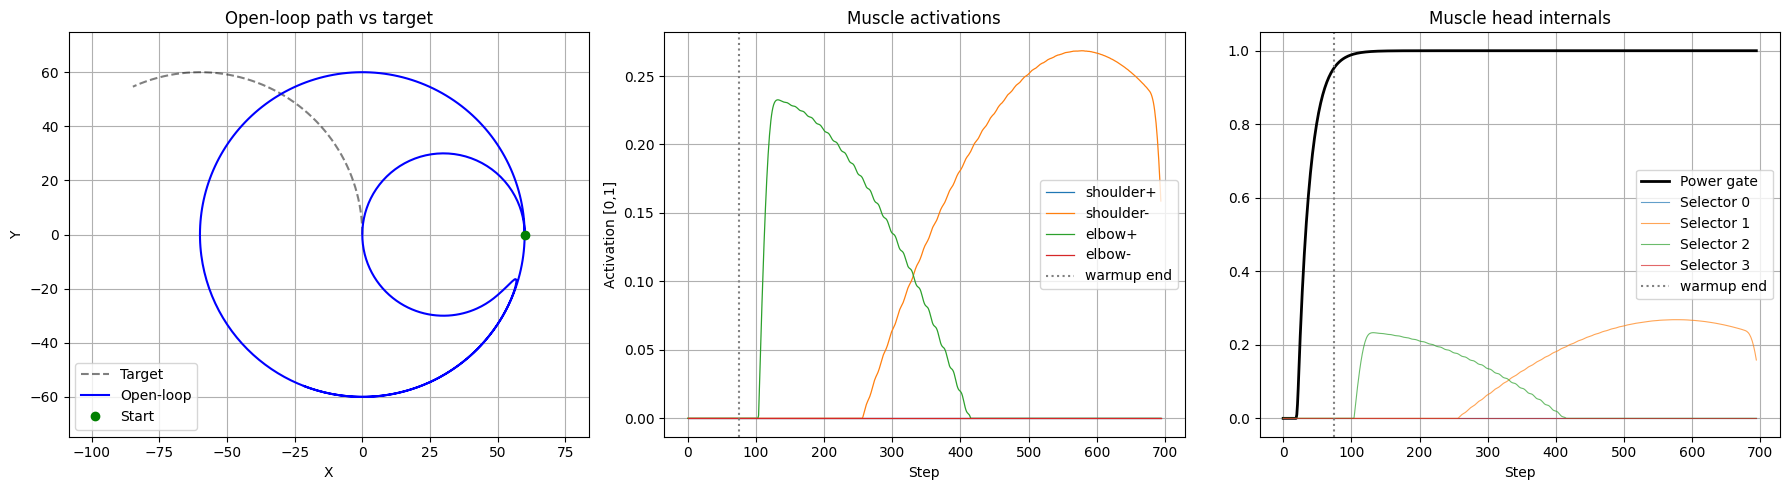


If power gate < 0.9 or shoulder muscles silent, STOP here and fix POWER_CYCLES_PER_STEP.


In [108]:
def validate_latent_plan(ann, arm_ref, latent_plan, drawing_pos, warmup_steps):
    """
    Open-loop rollout through muscle head → arm.
    Does NOT touch the Brain. Resets ann and arm state before running.
    Returns predicted hand positions and debug dict.
    """
    ann.muscle_head.reset_state(batch_size=1)

    # Save and reset arm so rollout starts from neutral
    saved_sh = arm_ref._shoulder_angle
    saved_el = arm_ref._elbow_angle
    arm_ref._shoulder_angle = 0.0
    arm_ref._elbow_angle    = 0.0

    latent_tensor = torch.tensor(latent_plan, dtype=torch.float32)
    with torch.no_grad():
        muscle_acts_t, debug = ann.muscle_head(latent_tensor, return_debug=True)
    muscle_acts = muscle_acts_t.numpy()

    T = len(latent_plan)
    predicted = np.zeros((T, 2))
    for k in range(T):
        arm_ref.move(*muscle_acts[k])
        predicted[k] = arm_ref.hand_pos

    # Restore arm state
    arm_ref._shoulder_angle = saved_sh
    arm_ref._elbow_angle    = saved_el

    # ── Metrics ───────────────────────────────────────────────────────
    drawing_pred  = predicted[warmup_steps:warmup_steps + len(drawing_pos)]
    pos_error     = np.linalg.norm(drawing_pred - drawing_pos, axis=1)
    rmse          = np.sqrt(np.mean(pos_error**2))
    power_np      = debug['power'].numpy()
    max_power     = power_np[warmup_steps:].max()

    print(f"Open-loop RMSE (drawing phase)  : {rmse:.3f} units")
    print(f"Peak power gate (post-warmup)   : {max_power:.3f}  (target > 0.9)")
    print(f"Mean muscle acts [sh+,sh-,el+,el-]: {muscle_acts[warmup_steps:].mean(axis=0).round(3)}")

    if max_power < 0.9:
        print("  ⚠ Power gate did not saturate — check POWER_CYCLES_PER_STEP or increase WARMUP_STEPS")
    else:
        print("  ✓ Power gate saturated.")

    if muscle_acts[warmup_steps:, :2].max() < 0.05:
        print("  ⚠ Shoulder muscles never fired — steering frequencies may be wrong")
    else:
        print("  ✓ Shoulder muscles active.")

    # ── Plots ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax = axes[0]
    ax.plot(drawing_pos[:, 0], drawing_pos[:, 1], 'k--', alpha=0.5, label='Target')
    ax.plot(drawing_pred[:, 0], drawing_pred[:, 1], 'b-', lw=1.5, label='Open-loop')
    ax.plot(drawing_pred[0, 0], drawing_pred[0, 1], 'go', label='Start')
    ax.set_title('Open-loop path vs target')
    ax.set_xlabel('X'); ax.set_ylabel('Y')
    ax.axis('equal'); ax.grid(True); ax.legend()

    ax = axes[1]
    for i, lbl in enumerate(MUSCLE_LABELS):
        ax.plot(muscle_acts[:, i], label=lbl, lw=0.9)
    ax.axvline(warmup_steps, color='gray', linestyle=':', label='warmup end')
    ax.set_title('Muscle activations')
    ax.set_xlabel('Step'); ax.set_ylabel('Activation [0,1]')
    ax.legend(); ax.grid(True)

    ax = axes[2]
    ax.plot(power_np, 'k-', lw=2, label='Power gate')
    sel = debug['selector'].numpy()
    for i in range(4):
        ax.plot(sel[:, i], lw=0.8, alpha=0.7, label=f'Selector {i}')
    ax.axvline(warmup_steps, color='gray', linestyle=':', label='warmup end')
    ax.set_title('Muscle head internals')
    ax.set_xlabel('Step'); ax.legend(); ax.grid(True)

    plt.tight_layout()
    plt.show()

    return predicted, muscle_acts, {k: v.numpy() for k, v in debug.items()}


# ── Instantiate system (used only for its ann and arm here) ───────────
brain_ol  = Brain(random_seed=RANDOM_SEED)
system_ol = BMI_and_Hand(brain_ol)

# ── Run open-loop validation — MUST pass before continuing ────────────
ol_pred, ol_muscles, ol_debug = validate_latent_plan(
    system_ol.ann, system_ol._arm,
    latent_plan, drawing_pos, WARMUP_STEPS
)
print("\nIf power gate < 0.9 or shoulder muscles silent, STOP here and fix POWER_CYCLES_PER_STEP.")

---
## Stage 3 — System identification

Only proceed here if Stage 2 passed.

We wrap the system so the controller sees a 2D output (the W_total
projection of the 16D neural measurement), then identify a linear
state-space model of this wrapped system.

In [109]:
from bmi_controller import LatentBrainWrapper

# Fresh system for system ID — separate from the open-loop instance
np.random.seed(RANDOM_SEED)
brain_id  = Brain(random_seed=RANDOM_SEED)
system_id = BMI_and_Hand(brain_id)
wrapper   = LatentBrainWrapper(system_id, W_TOTAL)

print("Running system identification...")
print(f"  n_dominant={N_DOMINANT}, n_hidden={N_HIDDEN}")
print(f"  {NUM_TRIALS} trials × {N_SAMPLES_PER_TRIAL} samples each")

lds, vaf = extract_full_orthogonal_model(
    wrapper,
    n_dominant=N_DOMINANT,
    n_hidden=N_HIDDEN,
    n_samples_per_trial=N_SAMPLES_PER_TRIAL,
    num_trials=NUM_TRIALS,
    verbose=True
)

A, B, C   = lds.A, lds.B, lds.C
Q_sys, R_sys = lds.Q, lds.R
n_states  = A.shape[0]

print(f"\nVAF            : {vaf:.3f}  (threshold: {VAF_THRESHOLD})")
print(f"State dim      : {n_states}")
print(f"A shape        : {A.shape}")
print(f"B shape        : {B.shape}")
print(f"C shape        : {C.shape}")

assert vaf >= VAF_THRESHOLD, (
    f"VAF {vaf:.3f} below threshold {VAF_THRESHOLD}. "
    "Increase NUM_TRIALS or N_SAMPLES_PER_TRIAL before continuing."
)
print("\n✓ VAF acceptable. Proceeding to controller design.")

Running system identification...
  n_dominant=2, n_hidden=1
  5 trials × 400 samples each

████████████████████████████████████████████████████████████
INITIATING MASTER ORTHOGONAL PIPELINE (3 STATES)
████████████████████████████████████████████████████████████

════════════════════════════════════════════════════════════
STAGE 1: EXTRACTING 2 DOMINANT STATES
════════════════════════════════════════════════════════════
Step 1: Data collection
  Settling (200 steps) at baseline 0.5...

Step 2: Selecting latent dimension
  Forced LatentDim = 2 (User overridden)

Step 3: Selecting num_lags
  Selected num_lags  = 6

Step 4: N4SID + EM identification
  [1/2] N4SID initialisation...
  [info] Shapes: A=(2, 2), B=(2, 2), C=(2, 2), Q=(2, 2), R=(2, 2), Y=(320, 2), U=(320, 2)
  [2/2] EM refinement...
    iter   1  ll=-955.945  Δll=+inf
    iter   2  ll=-317.005  Δll=+6.389e+02
    iter   3  ll=-224.446  Δll=+9.256e+01
    iter   4  ll=-161.637  Δll=+6.281e+01
    iter   5  ll=-120.942  Δll=+4.070

---
## Stage 4 — Controller design

MPC cost matrices are sized to match the identified state dimension.
No hardcoded eye(2) — always eye(n_states).

In [110]:
# Derive dimensions from identified matrices — never hardcode
n_outputs = C.shape[0]   # dimension of y = C @ x  (= 2, the latent output)
n_inputs  = B.shape[1]   # dimension of u

estimator = AugmentedKalmanFilter(
    A, B, C, Q_sys, R_sys,
    Q_disturbance=KF_Q_DIST
)

# Q_cost must be (n_outputs, n_outputs) because the MPC cost is computed
# on the OUTPUT error  e = C @ x_pred - y_ref,  not on the state directly.
# R_cost must be (n_inputs, n_inputs).
mpc = ConstrainedMPC(
    A, B, C,
    horizon=MPC_HORIZON,
    Q_cost=np.eye(n_outputs) * MPC_Q,
    R_cost=np.eye(n_inputs)  * MPC_R
)

print("Controller design:")
print(f"  n_states  : {n_states}")
print(f"  n_outputs : {n_outputs}  ← Q_cost is ({n_outputs}×{n_outputs})")
print(f"  n_inputs  : {n_inputs}   ← R_cost is ({n_inputs}×{n_inputs})")
print(f"  MPC horizon  : {MPC_HORIZON}")
print(f"  Q weight     : {MPC_Q}")
print(f"  R weight     : {MPC_R}")
print(f"  KF Q_dist    : {KF_Q_DIST}")

# Controllability check
from numpy.linalg import matrix_rank
ctrl_mat = np.hstack([np.linalg.matrix_power(A, i) @ B for i in range(n_states)])
rank = matrix_rank(ctrl_mat)
print(f"\nControllability matrix rank: {rank} / {n_states}")
if rank < n_states:
    print("  ⚠ System is not fully controllable.")
else:
    print("  ✓ System is fully controllable.")

Controller design:
  n_states  : 3
  n_outputs : 2  ← Q_cost is (2×2)
  n_inputs  : 2   ← R_cost is (2×2)
  MPC horizon  : 20
  Q weight     : 1000.0
  R weight     : 10.0
  KF Q_dist    : 0.05

Controllability matrix rank: 3 / 3
  ✓ System is fully controllable.


---
## Stage 5 — Closed-loop execution

The wrapper, estimator, and MPC all use the same system instance.
The latent_plan index starts at 0 = first warmup step, so the
controller naturally idles during warmup (zero-velocity feedforward)
before the drawing phase begins.

Total steps run = WARMUP_STEPS + SIM_STEPS.

In [ ]:
def run_closed_loop(wrapper, estimator, mpc, C, latent_plan,
                    total_steps, warmup_steps):
    """
    Closed-loop MPC tracking over total_steps steps.

    The MPC cost is computed in OUTPUT space: error = C @ x_pred - y_ref.
    So target_trajectory_window must be (horizon, n_outputs) — the same
    dimension as C @ x, which is 2. No C_pinv projection needed.

    Returns:
        history_hand  : (total_steps, 2) — XY hand positions
        history_latent: (total_steps, 2) — measured latent (W·y)
    """
    horizon = mpc.horizon
    u_prev  = np.zeros(n_inputs)   # n_inputs set in Stage 4

    history_hand   = np.zeros((total_steps, 2))
    history_latent = np.zeros((total_steps, 2))

    for k in range(total_steps):
        # 1. Measure current latent state
        y_k = wrapper.measure()

        # 2. Record hand position BEFORE stepping
        history_hand[k]   = wrapper.system.hand_pos
        history_latent[k] = y_k

        # 3. Kalman update
        x_hat, d_hat = estimator.update(y_k, u_prev)

        # 4. Extract output-space target window and correct for disturbance
        #    Shape: (horizon, n_outputs) = (horizon, 2) — matches C @ x
        target_window   = latent_plan[k : k + horizon]          # (horizon, 2)
        adjusted_target = target_window - d_hat.flatten().reshape(-1, 2)

        # 5. MPC solve — pass output-space reference directly
        #    MPC handles C @ x internally; reference must match output dim
        u_k = mpc.get_input(x_hat, adjusted_target)

        # 6. Apply to system
        wrapper.next_state(u_k)
        u_prev = u_k

    return history_hand, history_latent


# ── Fresh system for closed-loop (estimator state must be clean) ──────
np.random.seed(RANDOM_SEED)
brain_cl  = Brain(random_seed=RANDOM_SEED)
system_cl = BMI_and_Hand(brain_cl)
wrapper_cl = LatentBrainWrapper(system_cl, W_TOTAL)

# Re-instantiate estimator fresh
estimator_cl = AugmentedKalmanFilter(A, B, C, Q_sys, R_sys, Q_disturbance=KF_Q_DIST)

TOTAL_STEPS = WARMUP_STEPS + SIM_STEPS
print(f"Running closed-loop for {TOTAL_STEPS} steps ({WARMUP_STEPS} warmup + {SIM_STEPS} drawing)...")

history_hand, history_latent = run_closed_loop(
    wrapper_cl, estimator_cl, mpc, C,
    latent_plan, TOTAL_STEPS, WARMUP_STEPS
)

print("Simulation complete.")

Running closed-loop for 675 steps (75 warmup + 600 drawing)...
Simulation complete.


---
## Stage 6 — Diagnostics and plots

Closed-loop RMSE (drawing phase): 66.572 units
Max error                       : 84.986 units
Mean error                      : 65.325 units


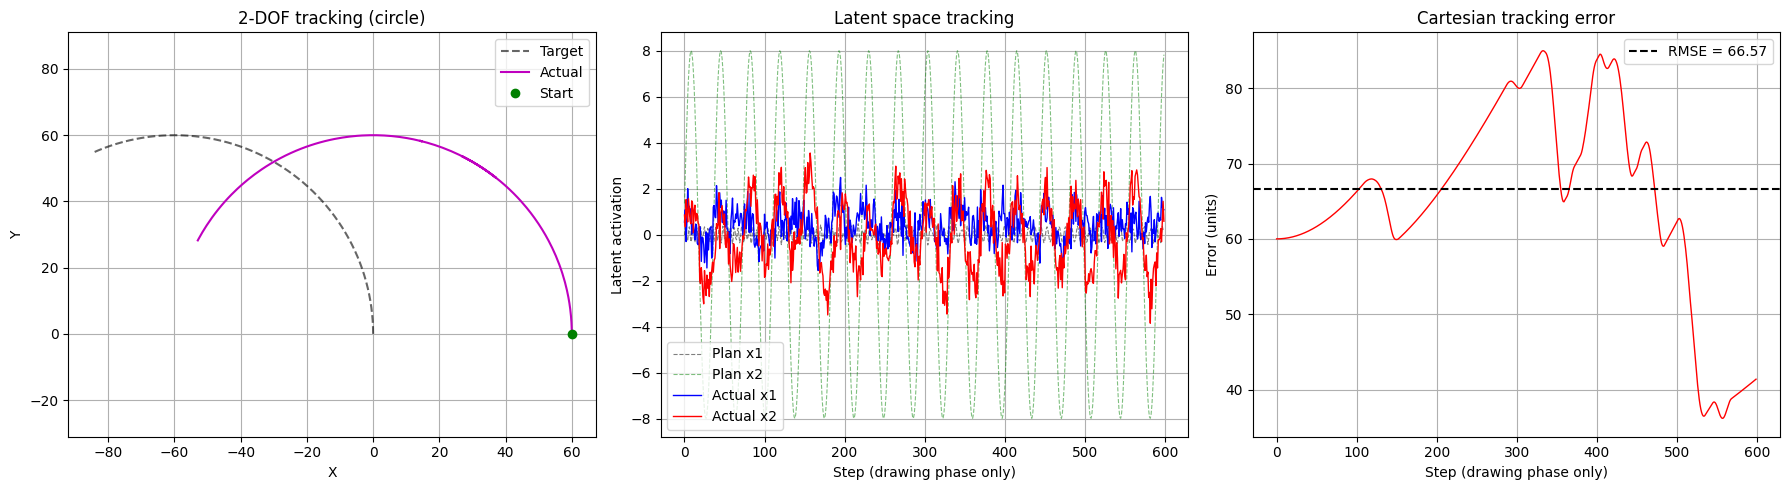

In [112]:
# =====================================================================
# STAGE 6 — DIAGNOSTICS
# Ground truth = open-loop ANN rollout from Stage 2 (ol_pred).
# This is the physically correct reference: where the arm actually goes
# when the latent plan is fed through the real ANN and arm model with
# no controller. Everything is measured against this.
# =====================================================================

# ── 1. Slice all signals to drawing phase only ────────────────────────
D = slice(WARMUP_STEPS, WARMUP_STEPS + SIM_STEPS)

ann_ref        = ol_pred[D]          # (SIM_STEPS, 2) — ANN ground truth arm path
drawing_hand   = history_hand[D]     # (SIM_STEPS, 2) — closed-loop arm path
drawing_latent = history_latent[D]   # (SIM_STEPS, 2) — closed-loop latent measurement
plan_drawing   = latent_plan[D]      # (SIM_STEPS, 2) — feedforward latent plan
steps          = np.arange(SIM_STEPS)

# ── 2. Metrics ────────────────────────────────────────────────────────
pos_error   = np.linalg.norm(drawing_hand - ann_ref, axis=1)
rmse        = np.sqrt(np.mean(pos_error**2))
ol_range_x  = ann_ref[:, 0].max() - ann_ref[:, 0].min()
ol_range_y  = ann_ref[:, 1].max() - ann_ref[:, 1].min()
rmse_pct    = rmse / np.mean([ol_range_x, ol_range_y]) * 100

x1_err = np.abs(drawing_latent[:, 0] - plan_drawing[:, 0])
x2_err = np.abs(drawing_latent[:, 1] - plan_drawing[:, 1])

print('══ Arm path metrics (vs ANN open-loop ground truth) ══')
print(f'  RMSE                : {rmse:.3f} arm units')
print(f'  Max error           : {pos_error.max():.3f} arm units')
print(f'  Mean error          : {pos_error.mean():.3f} arm units')
print(f'  RMSE as % of range  : {rmse_pct:.1f}%  '
      f'(X span={ol_range_x:.1f}, Y span={ol_range_y:.1f})')
print()
print('══ Latent tracking metrics ══')
print(f'  x1 mean abs error   : {x1_err.mean():.4f}')
print(f'  x2 mean abs error   : {x2_err.mean():.4f}')
print(f'  x2 actual mean      : {drawing_latent[:, 1].mean():.4f}  '
      f'(plan mean: {plan_drawing[:, 1].mean():.4f})')

# ── 3. Figure 1: Arm paths in physical space ──────────────────────────
# The only meaningful comparison: where did the arm actually go (magenta)
# vs where it would have gone with perfect open-loop (black dashed).
# drawing_pos is NOT used here — it lives in a different coordinate frame.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.plot(history_hand[:, 0], history_hand[:, 1],
        color='lightgray', lw=0.8, zorder=1,
        label='Full run incl. warmup')
ax.plot(ann_ref[:, 0], ann_ref[:, 1],
        'k--', lw=2.0, alpha=0.8, zorder=2,
        label='Open-loop ANN (ground truth)')
ax.plot(drawing_hand[:, 0], drawing_hand[:, 1],
        color='mediumorchid', lw=2.0, zorder=3,
        label='Closed-loop actual')
ax.plot(drawing_hand[0, 0],  drawing_hand[0, 1],
        'go', ms=10, zorder=4, label='Start')
ax.plot(drawing_hand[-1, 0], drawing_hand[-1, 1],
        'rs', ms=10, zorder=4, label='End')
ax.set_title(f'Arm path — closed-loop vs ANN ground truth\n'
             f'RMSE = {rmse:.2f} arm units ({rmse_pct:.1f}% of workspace)')
ax.set_xlabel('X (arm units)')
ax.set_ylabel('Y (arm units)')
ax.axis('equal'); ax.grid(True)
ax.legend(fontsize=8, loc='best')

ax = axes[1]
ax.plot(steps, pos_error, color='crimson', lw=1.2, label='Tracking error')
ax.fill_between(steps, pos_error, alpha=0.15, color='crimson')
ax.axhline(rmse, color='k', linestyle='--', lw=1.5,
           label=f'RMSE = {rmse:.2f}')
ax.set_title('Arm tracking error vs ANN ground truth')
ax.set_xlabel('Step (drawing phase only)')
ax.set_ylabel('Euclidean error (arm units)')
ax.legend(); ax.grid(True)

plt.tight_layout()
plt.show()

# ── 4. Figure 2: Latent signals ───────────────────────────────────────
# Shows whether the MPC successfully drove the brain to produce the
# intended x1 (steering) and x2 (power) signals.
# x2 not tracking the plan = power gate being suppressed by the MPC.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(steps, plan_drawing[:, 0],
        'k--', lw=0.8, alpha=0.5, label='Plan x1 (feedforward)')
ax.plot(steps, drawing_latent[:, 0],
        color='steelblue', lw=1.0, label='Actual x1')
ax.set_title(f'Latent x1 — steering signal\n'
             f'mean abs error = {x1_err.mean():.4f}')
ax.set_xlabel('Step (drawing phase only)')
ax.set_ylabel('x1 activation')
ax.legend(); ax.grid(True)

ax = axes[1]
ax.plot(steps, plan_drawing[:, 1],
        'k--', lw=0.8, alpha=0.5, label='Plan x2 (power)')
ax.plot(steps, drawing_latent[:, 1],
        color='tomato', lw=1.0, label='Actual x2')
ax.set_title(f'Latent x2 — power signal\n'
             f'mean abs error = {x2_err.mean():.4f}')
ax.set_xlabel('Step (drawing phase only)')
ax.set_ylabel('x2 activation')
ax.legend(); ax.grid(True)

plt.tight_layout()
plt.show()